In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as mlt 
import seaborn as sns
mlt.style.use('fivethirtyeight')
import plotly.offline as py 
import plotly.graph_objs as go
import plotly.tools as tls

In [3]:
matches = pd.read_csv("C:/Users/kavya sri CM/Downloads/matches.csv")
delivery = pd.read_csv("C:/Users/kavya sri CM/Downloads/deliveries.csv")



In [4]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [5]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [6]:
###cleaning and transformation


In [7]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    object 
 3   date             636 non-null    object 
 4   team1            636 non-null    object 
 5   team2            636 non-null    object 
 6   toss_winner      636 non-null    object 
 7   toss_decision    636 non-null    object 
 8   result           636 non-null    object 
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    object 
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    object 
 14  venue            636 non-null    object 
 15  umpire1          635 non-null    object 
 16  umpire2          635 non-null    object 
 17  umpire3         

In [8]:
matches.drop(['umpire3'], axis = 1, inplace = True)          

In [9]:
delivery.fillna(0, inplace = True)

In [10]:
matches['team1'].unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],
      dtype=object)

In [11]:
matches.replace(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],['SRH', 'MI', 'GL', 'RSP', 'RCB', 'KKR', 'DD', 'KXIP', 'CSK', 'RR', 'DC', 'KTK', 'PW', 'RSP'], inplace = True)

delivery.replace(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],['SRH', 'MI', 'GL', 'RSP', 'RCB', 'KKR', 'DD', 'KXIP', 'CSK', 'RR', 'DC', 'KTK', 'PW', 'RSP'], inplace = True)


In [12]:
print("Total Matches Played", matches.shape[0])

print("\nvenues played at:", matches['city'].unique())

print("\nTeams:", matches['team1'].unique())

Total Matches Played 636

venues played at: ['Hyderabad' 'Pune' 'Rajkot' 'Indore' 'Bangalore' 'Mumbai' 'Kolkata'
 'Delhi' 'Chandigarh' 'Kanpur' 'Jaipur' 'Chennai' 'Cape Town'
 'Port Elizabeth' 'Durban' 'Centurion' 'East London' 'Johannesburg'
 'Kimberley' 'Bloemfontein' 'Ahmedabad' 'Cuttack' 'Nagpur' 'Dharamsala'
 'Kochi' 'Visakhapatnam' 'Raipur' 'Ranchi' 'Abu Dhabi' 'Sharjah' nan]

Teams: ['SRH' 'MI' 'GL' 'RSP' 'RCB' 'KKR' 'DD' 'KXIP' 'CSK' 'RR' 'DC' 'KTK' 'PW']


In [13]:
print("\nTotal played at:", matches['city'].nunique())

print("\nTotal Umpires:", matches['umpire1'].nunique())



Total played at: 30

Total Umpires: 44


In [14]:
print(matches['player_of_match'].value_counts().idxmax(), ": has the most number of Man of the Match awards")

print(matches['winner'].value_counts().idxmax(), ": has the highest number of match wins")

CH Gayle : has the most number of Man of the Match awards
MI : has the highest number of match wins


In [15]:
df = matches.iloc[[matches['win_by_runs'].idxmax()]]

df[['season','team1', 'team2', 'winner', 'win_by_runs']]

,season,team1,team2,winner,win_by_runs
43,2017,MI,DD,MI,146


In [16]:
df = matches.iloc[[matches['win_by_wickets'].idxmax()]]

df[['season','team1', 'team2', 'winner', 'win_by_wickets']]

,season,team1,team2,winner,win_by_wickets
2,2017,GL,KKR,KKR,10


Toss Decision

In [17]:
print("Toss Decision in %\n", ((matches['toss_decision']).value_counts(normalize = True))*100)

Toss Decision in %
 toss_decision
field    57.075472
bat      42.924528
Name: proportion, dtype: float64


Toss Decisions across Seasons


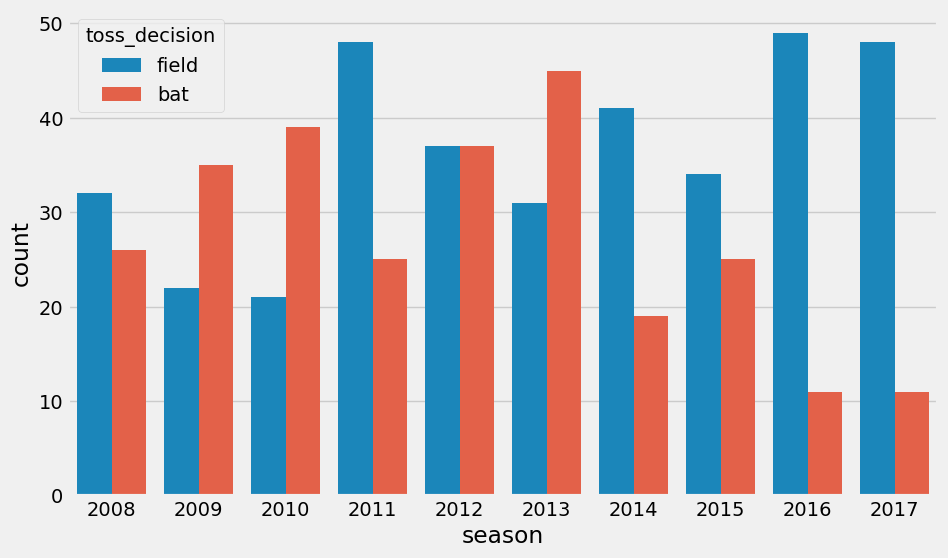

In [18]:
mlt.subplots(figsize = (10,6))
sns.countplot(x = 'season', hue = 'toss_decision', data = matches)
mlt.show()

Max Toss Winners 

NameError: name 'ax' is not defined

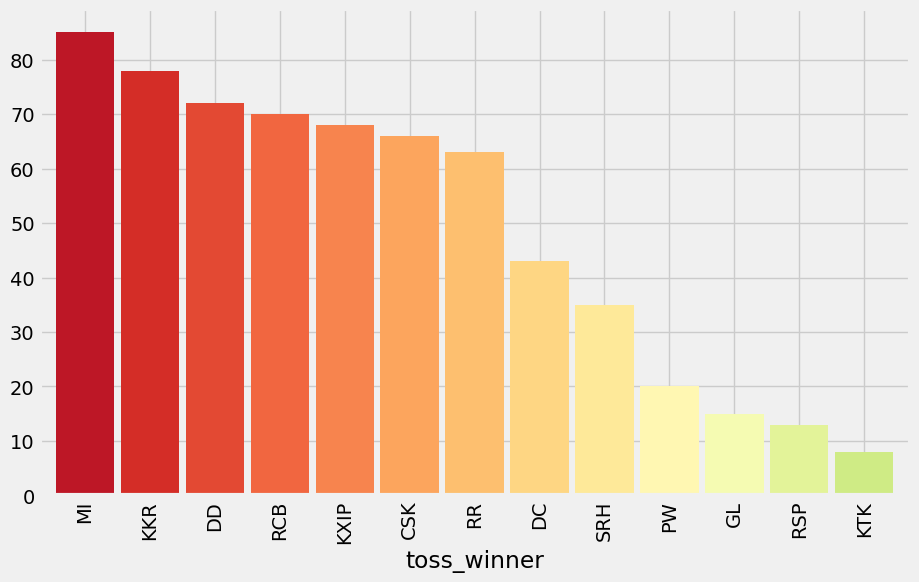

In [19]:
mlt.subplots(figsize = (10,6))

matches['toss_winner'].value_counts().plot.bar(width = 0.9, color = sns.color_palette('RdYlGn', 20))
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.15, p.get_height() + 1))

mlt.show()

Total Matches vs Wins for Teams

In [ ]:
# Total matches played by each team
matches_played_by_teams = pd.concat([matches['team1'], matches['team2']])

matches_played_by_teams = (
    matches_played_by_teams
    .value_counts()
    .reset_index()
)

matches_played_by_teams.columns = ['Team', 'Total Matches']

# Total wins
wins = (
    matches['winner']
    .value_counts()
    .reset_index()
)

wins.columns = ['Team', 'wins']

# Merge
matches_played_by_teams = matches_played_by_teams.merge(
    wins,
    on='Team',
    how='left'
)

matches_played_by_teams['wins'] = matches_played_by_teams['wins'].fillna(0)

matches_played_by_teams.set_index('Team', inplace=True)

trace1 = go.Bar(
    x=matches_played_by_teams.index,
    y=matches_played_by_teams['Total Matches'],
    name='Total Matches'
)

trace2 = go.Bar(
    x=matches_played_by_teams.index,
    y=matches_played_by_teams['wins'],
    name='Matches Won'
)

data = [trace1, trace2]

layout = go.Layout(
    barmode='stack'
)

fig = go.Figure(data=data, layout=layout)

fig.show()

Is Toss Winner also the Match winner 

In [ ]:
matches.shape

In [ ]:
len(df)

In [ ]:
df = matches[matches['toss_winner'] == matches['winner']]

slices = [len(df), (636 - len(df))]

labels = ['yes', 'no']

mlt.pie(slices, labels = labels,
        startangle = 90,
        shadow = True,
       explode = (0,0.1),
       autopct = "1.1f%%",
       colors = ['r','g'])

fig = mlt.gcf()

fig.set_size_inches(6,6)

mlt.show()

In [ ]:
import warnings
warnings.filterwarnings('ignore')

mlt.subplots(figsize = (10,6))

sns.countplot(x = 'season', data = matches, palette = sns.color_palette("winter"))

mlt.show()                                                                        

Runs Across the Season

In [ ]:
batsmen = matches[['id','season']].merge(delivery,
                               left_on = 'id',
                               right_on = 'match_id',
                               how = 'left').drop('id', axis = 1)
season = batsmen.groupby(['season'])['total_runs'].sum().reset_index()

season.set_index('season').plot(marker = 'o')  

mlt.gcf().set_size_inches(10,6)

mlt.title("Total Runs Across the Seasons")

mlt.show()

Average Runs per Match in each Season 

In [ ]:
avgruns_each_season = matches.groupby(['season']).count().id.reset_index()

avgruns_each_season.rename(columns = {'id':'matches'},inplace = True)

avgruns_each_season['total_runs'] = season['total_runs']

avgruns_each_season['average_runs_per_match'] = avgruns_each_season['total_runs'] / avgruns_each_season['total_runs'] / avgruns_each_season['matches']

avgruns_each_season.set_index('season')['average_runs_per_match'].plot(marker = 'o')

mlt.gcf().set_size_inches(10,6)

mlt.title('Average Runs Per Match Across Season')

mlt.show()

Sixes and Fours Across the Season

In [ ]:
import matplotlib.pyplot as plt

# Count sixes
season_boundaries = batsmen.groupby("season")['batsman_runs'].agg(
    lambda x: (x == 6).sum()
).reset_index()

# Count fours
a = batsmen.groupby("season")['batsman_runs'].agg(
    lambda x: (x == 4).sum()
).reset_index()

# Merge
season_boundaries = season_boundaries.merge(
    a,
    on='season',
    how='left'
)

# Rename columns
season_boundaries.rename(
    columns={
        'batsman_runs_x': "6's",
        'batsman_runs_y': "4's"
    },
    inplace=True
)

# Plot
season_boundaries.set_index('season')[["6's", "4's"]].plot(marker='o')

fig = plt.gcf()
fig.set_size_inches(10, 6)

plt.show()

Runs Per Over By Teams Across Season

In [ ]:
runs_per_over = delivery.pivot_table(
    index='over',
    columns='batting_team',
    values='total_runs',
    aggfunc='sum'
)

runs_per_over[
    matches_played_by_teams[
        matches_played_by_teams['Total Matches'] > 50
    ].index
].plot(
    color=['b', 'r', '#FFB6B2', 'g', 'brown', 'y', '#6666FF', 'black', '#FFA500']
)

plt.xticks(range(1, 21))
plt.ylabel('Total Runs Scored')

fig = plt.gcf()
fig.set_size_inches(10, 6)

plt.show()

In [ ]:
mlt.subplots(figsize = (10,15))

ax = matches['venue'].value_counts().sort_values(ascending = True).plot.barh(width = 0.9, color = sns.color_palette('inferno', 40))

ax.set_xlabel('Grounds')

ax.set_ylabel('Count')

mlt.show()

Maximum Man of Matches

In [ ]:
mlt.subplots(figsize = (10,6))

ax = matches['player_of_match'].value_counts().head(10).plot.bar(width = 0.8, color = sns.color_palette('inferno', 10))

ax.set_xlabel('player_of_match')

ax.set_ylabel('count')

for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.15, p.get_height() + 0.25))

mlt.show()    

Winner by Year 

In [ ]:
print('Winner By Years')

for i in range(2008,2017):
    df = ((matches[matches['season'] == i]).iloc[-1])
    print(df[[1,10]].values)

Super Over

In [ ]:
print("\n Total Matches with Super Overs:", delivery[delivery['is_super_over'] ==1].match_id.nunique())

In [ ]:
teams = ['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR', 'DD', 'GL', 'KXIP', 'SRH', 'RPS', 'KTK', 'PW']
play = delivery[delivery['is_super_over'] == 1].batting_team.unique()
play = list(play)

print("Teams who haven't ever played a super overs are:", list(set(teams) - set(play)))

Favorite Umpires:

In [ ]:
mlt.subplots(figsize = (10,6))
ump = pd.concat([matches['umpire1'], matches['umpire2']])

ump.value_counts().head(10).plot.bar(width = 0.8, color = sns.color_palette('summer', 10))

for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.15, p.get_height() + 0.25))

mlt.show()

Team1 vs Team2

MI vs KKR

In [ ]:
import warnings
warnings.filterwarnings('ignore')
def team1_vs_team2(team1, team2):
    mt1 = matches[((matches['team1'] == team1) | (matches['team2'] == team1)) & ((matches['team1'] == team2) | (matches['team2'] == team2))]
    sns.countplot(x = 'season', hue = 'winner', data = mt1, palette = 'Set3')
    mlt.xticks(rotation = 'vertical')
    leg = mlt.legend( loc = 'upper center')
    fig = mlt.gcf()
    fig.set_size_inches(10,6)
    mlt.show()

In [ ]:
team1_vs_team2('KKR', 'MI')

Matches Won By a Team Against Other Teams

In [ ]:
def comparator(team1):
    teams = ['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR', 'DD', 'GL', 'KXIP', 'SRH', 'RPS', 'KTK', 'PW']
    teams.remove(team1)
    opponents = teams.copy()
    mt1 = matches[((matches['team1'] == team1) | (matches['team2'] == team1))]
    for i in opponents:
        mask = (((mt1['team1'] == i) | (mt1['team2'] == i))) & ((mt1['team1'] == team1) | (mt1['team2'] == team1))
        mt2 = mt1.loc[mask, 'winner'].value_counts().to_frame().T
        print(mt2)
        

In [ ]:
comparator('MI')


Score Distribution For Teams by Innings

In [ ]:
mlt.subplots(figsize = (10,6))

xyz = delivery.groupby(['match_id', 'inning', 'batting_team'])['total_runs'].sum().reset_index()

xyz.drop('match_id', axis = 1, inplace = True)

xyz = xyz.sort_values(by = ['batting_team', 'total_runs'], ascending = True)

score_1_inning = xyz[xyz['inning'] == 1]

score_2_inning = xyz[xyz['inning'] == 2]

sns.boxplot(x = 'batting_team', y = 'total_runs', data = score_1_inning).set_title("1st Innings")

mlt.show()

sns.boxplot(x = 'batting_team', y = 'total_runs', data = score_2_inning).set_title("2nd Innings")

fig = mlt.gcf()

fig.set_size_inches(12,6)

200+ Scores

In [ ]:
high_scores = delivery.groupby(['match_id', 'inning', 'batting_team', 'bowling_team'])['total_runs'].sum().reset_index()

high_scores = high_scores[high_scores['total_runs'] >= 200]

high_scores.nlargest(10, 'total_runs')

In [ ]:
fig, ax = mlt.subplots(1, 2)

sns.countplot(high_scores['batting_team'],ax = ax[0])

sns.countplot(high_scores['bowling_team'], ax = ax[1])

mlt.xticks(rotation = 90)

fig = mlt.gcf()

fig.set_size_inches(18,6)

mlt.show()

In [ ]:
print("Teams who have not ever scored 200+ runs:",list(set(teams) - set(high_scores['batting_team'])))

print("Teams who have not conceeded over 200+ runs:",list(set(teams) - set(high_scores['bowling_team'])))

In [ ]:
high = delivery.groupby(['match_id', 'inning', 'batting_team', 'bowling_team'])['total_runs'].sum().reset_index()
high.set_index(['match_id'], inplace = True)

high['total_runs'].max()

high = high.rename(columns = {'total_runs': 'count'})

high = high[high['count'] >= 200].groupby(['inning', 'batting_team', 'bowling_team']).count()

high

In [ ]:
# Total runs scored by each team in each innings
high_scores = delivery.groupby(
    ['match_id', 'inning', 'batting_team', 'bowling_team']
)['total_runs'].sum().reset_index()

# Separate 1st innings and 2nd innings
high_scores1 = high_scores[high_scores['inning'] == 1]
high_scores2 = high_scores[high_scores['inning'] == 2]

# Merge both innings using match_id
high_scores1 = high_scores1.merge(
    high_scores2[['match_id', 'inning', 'total_runs']],
    on='match_id'
)

# Rename columns
high_scores1 = high_scores1.rename(columns={
    'inning_x': 'inning_1',
    'inning_y': 'inning_2',
    'total_runs_x': 'inning1_runs',
    'total_runs_y': 'inning2_runs'
})

# Keep only matches where first innings score is 200 or more
high_scores1 = high_scores1[high_scores1['inning1_runs'] >= 200]

# Check whether the target was chased successfully
high_scores1['is_score_chased'] = np.where(
    high_scores1['inning2_runs'] >= high_scores1['inning1_runs'],
    'yes',
    'no'
)

# Display result
high_scores1.head()

Chances of Chasing 200+ target

In [ ]:
high_scores1['is_score_chased'].map({'yes':1, 'no':0}).value_counts()

labels = ['target not chased', 'target chased']

mlt.pie(slices, labels = labels, colors = ['#1f2ff3', '#0fff00'], startangle = 90, shadow = True, explode = (0,0.1), autopct = '%1.1f%%')

fig = mlt.gcf()

fig.set_size_inches(6,6)

mlt.show()

Batsman Comparator

In [ ]:
balls = delivery.groupby(['batsman'])['ball'].count().reset_index()


In [ ]:
runs = delivery.groupby(['batsman'])['batsman_runs'].sum().reset_index()

In [ ]:
balls = balls.merge(runs, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [ ]:
balls.rename({"ball": "ball_x", "batsman_runs": "ball_y"}, axis = 1, inplace = True)

In [ ]:
fours = delivery.groupby('batsman')['batsman_runs'].agg(lambda x: (x ==4).sum()).reset_index()

In [ ]:
sixes = delivery.groupby('batsman')['batsman_runs'].agg(lambda x: (x ==4).sum()).reset_index()

In [ ]:
balls['strike_rate'] = balls['ball_y'] / balls['ball_x'] * 100

In [ ]:
balls = balls.merge(sixes, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [ ]:
balls = balls.merge(fours, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [ ]:
compare = delivery.groupby(['match_id', 'batsman', 'batting_team'])['batsman_runs'].sum().reset_index()

In [ ]:
compare


In [ ]:
compare = compare.groupby(['batsman', 'batting_team'])['batsman_runs'].max().reset_index()

In [ ]:
balls = balls.merge(compare,left_on = 'batsman', right_on = 'batsman', how ='outer')

In [ ]:
balls.rename({'ball_x': 'balls', 'ball_y': 'runs', 'batsman_runs_x': "6's", "batsman_runs_y": "4's", 'batting_team':"Team", "batsman_runs": "heighest_score"}, axis = 1, inplace = True)

In [ ]:
balls.head()

In [ ]:
def batsman_comparator(stat1, stat2, batsman1, batsman2):

    sns.FacetGrid(
        balls,
        hue='Team',
        height=8
    ).map(plt.scatter, stat1, stat2, alpha=0.5).add_legend()

    bats1 = balls[balls['batsman'].str.contains(batsman1)].sort_values(
        by=stat1, ascending=False
    )

    bats2 = balls[balls['batsman'].str.contains(batsman2)].sort_values(
        by=stat1, ascending=False
    )

    plt.scatter(
        bats1[stat1],
        bats1[stat2],
        s=75,
        c='#55ff33'
    )

    plt.text(
        x=bats1[stat1].values[0],
        y=bats1[stat2].values[0],
        s=batsman1,
        fontsize=10,
        weight='bold',
        color='#f46d43'
    )

    plt.scatter(
        bats2[stat1],
        bats2[stat2],
        s=75,
        c='#f73545'
    )

    plt.text(
        x=bats2[stat1].values[0],
        y=bats2[stat2].values[0],
        s=batsman2,
        fontsize=10,
        weight='bold',
        color='#ff58fd'
    )

    plt.gcf().set_size_inches(15,10)
    plt.title('Batsman Comparator', fontsize=25)
    plt.show()

In [ ]:
batsman_comparator("6's", "4's", "Gayle", "Villiers")

In [ ]:
batsman_comparator("runs", "strike_rate", "Dhoni", "V Kohli")

Top 10 Batsman

In [ ]:
mlt.subplots(figsize = (10,6))

max_runs = delivery.groupby(['batsman'])['batsman_runs'].sum()

ax = max_runs.sort_values(ascending = False)[:10].plot.bar(width = 0.8, color = sns.color_palette("winter_r", 20))

for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.1, p.get_height() + 50), fontsize = 15)
mlt.show()

Top Btasman's with 1's, 2's, 3's, 4's

In [ ]:
toppers = delivery.groupby(['batsman', 'batsman_runs'])['total_runs'].count().reset_index()
toppers = toppers.pivot_table(index = "batsman", columns = "batsman_runs", values = "total_runs", fill_value = 0)

fid, ax = mlt.subplots(2, 2, figsize = (18, 12))

toppers[1].sort_values(ascending = False)[:5].plot(kind = 'barh', ax = ax[0,0], color = "#45ff45", width = 0.8)
ax[0,0].set_title("Most 1's")
ax[0,0].set_ylabel("")

toppers[2].sort_values(ascending = False)[:5].plot(kind = 'barh', ax = ax[0,1], color = "#df6dfd", width = 0.8)
ax[0,1].set_title("Most 2's")
ax[0,1].set_ylabel("")

toppers[4].sort_values(ascending = False)[:5].plot(kind = 'barh', ax = ax[1,0], color = "#fbca5f", width = 0.8)
ax[1,0].set_title("Most 4's")
ax[1,0].set_ylabel("")

toppers[6].sort_values(ascending = False)[:5].plot(kind = 'barh', ax = ax[1,1], color = "#ffff00", width = 0.8)
ax[1,1].set_title("Most 6's")
ax[1,1].set_ylabel("")

mlt.show()

Top Induvidual Scores

In [ ]:
top_scores = delivery.groupby(['match_id', "batsman", 'batting_team'])['batsman_runs'].sum().reset_index()

top_scores.sort_values('batsman_runs', ascending = 0).head(10)

top_scores.nlargest(10, 'batsman_runs')

Induvidual Scores by Top Batsman each Inning

In [ ]:
swarm = [' CH Gayle', 'V Kohli', 'G Gambir', 'SK Raina', 'YK Pathan', 'MS Dhoni', 'AB de Villiers', 'Da Warner']

scores = delivery.groupby(['match_id', 'batsman', 'batting_team'])['batsman_runs'].sum().reset_index()

scores = scores[top_scores['batsman'].isin(swarm)]

sns.swarmplot(x = 'batsman', y = 'batsman_runs', data = scores,
              hue = 'batting_team',
              palette = 'Set2')
fig = mlt.gcf()

fig.set_size_inches(14, 8)

mlt.ylim(-10, 200)

mlt.show()

Runs Scores by Batsman Across Seasons

In [ ]:
a = batsmen.groupby(['season', 'batsman'])['batsman_runs'].sum().reset_index()

a = a.groupby(['season', 'batsman'])['batsman_runs'].sum().unstack().T

a['Total'] = a.sum(axis = 1)

a = a.sort_values(by = 'Total', ascending = 0)[:5]

a.drop('Total', axis = 1, inplace = True)

a.T.plot(color = ['red', 'blue', '#772272', 'green', '#f0ff00'], marker = 'o')

fig = mlt.gcf()

fig.set_size_inches(16, 6)

mlt.show()

Frequency of Scores

In [ ]:
mlt.subplots(figsize = (10,6))

bins = range(0, 180, 10)

mlt.hist(top_scores['batsman_runs'], bins, histtype = 'bar', width = 1.2, color = '#0ff0ff')

mlt.xlabel('Runs')

mlt.ylabel('Count')

mlt.axvline(top_scores['batsman_runs'].mean(),color = 'b', linestyle = 'dashed', linewidth = 2)
mlt.plot()
mlt.show()


Orange Caps Each Season (Highest Run Getter Per Season)

In [ ]:
import plotly.graph_objs as go

orange = matches[['id', 'season']]

orange = orange.merge(
    delivery,
    left_on='id',
    right_on='match_id',
    how='left'
)

orange = orange.groupby(
    ['season', 'batsman']
)['batsman_runs'].sum().reset_index()

orange = orange.sort_values(
    by='batsman_runs',
    ascending=False
)

orange = orange.drop_duplicates(
    subset=['season'],
    keep='first'
)

orange = orange.sort_values(by='season')

trace1 = go.Bar(
    x=orange['season'],
    y=orange['batsman_runs'],
    name='Orange Cap Runs',
    text=orange['batsman'],
    marker=dict(
        color='rgb(255, 140, 0)',
        line=dict(
            color='rgb(8, 48, 107)',
            width=1.5
        )
    ),
    opacity=1
)

layout = go.Layout(
    title='Orange Cap Holders'
)

fig = go.Figure(
    data=[trace1],
    layout=layout
)

py.iplot(fig, filename='orange-cap-holders')

Top Bowlers

Highest Wicket Taker 

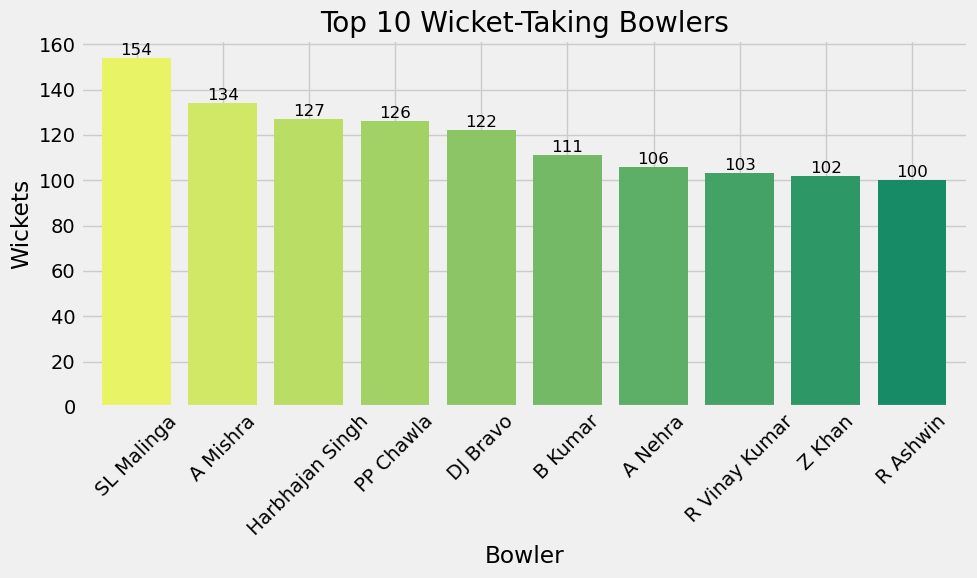

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplots(figsize=(10, 6))

dismissal_kinds = [
    'bowled',
    'caught',
    'lbw',
    'stumped',
    'caught and bowled',
    'hit wicket'
]

# Filter the dataframe
ct = delivery[delivery['dismissal_kind'].isin(dismissal_kinds)]

# Top 10 wicket-taking bowlers
ax = ct['bowler'].value_counts()[:10].plot.bar(
    width=0.8,
    color=sns.color_palette('summer_r', 10)
)

# Add value labels
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.title("Top 10 Wicket-Taking Bowlers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Maximum Overs 

In [26]:
eco = delivery.groupby(['bowler']).sum(numeric_only = True)
eco['total balls'] = delivery['bowler'].value_counts()
eco['overs'] = (eco['total balls']//6)
eco[eco['overs'] > 200].sort_values(by = 'overs',ascending = 0)['overs'].head(5).reset_index()

,bowler,overs
0,Harbhajan Singh,498
1,A Mishra,450
2,SL Malinga,449
3,P Kumar,439
4,PP Chawla,432


In [30]:
eco['economy'] = (eco['total_runs'] / (eco['overs']))

eco[eco['overs'] > 300].sort_values('economy')[:10].economy.reset_index().T

,0,1,2,3,4,5,6,7,8,9
bowler,SP Narine,R Ashwin,DW Steyn,SL Malinga,Harbhajan Singh,B Kumar,A Mishra,PP Ojha,Z Khan,P Kumar
economy,6.395706,6.493639,6.615599,6.757238,6.933735,7.046784,7.344444,7.404321,7.546174,7.612756


Top 20 Bowlers

In [31]:
bowlers = delivery.groupby('bowler').sum(numeric_only = True).reset_index()

In [36]:
# Runs given by each bowler
bowlers = delivery.groupby('bowler')['total_runs'].sum().reset_index()

# Balls bowled by each bowler
bowl = delivery['bowler'].value_counts().reset_index()
bowl.columns = ['bowler', 'balls']

# Convert datatype
bowl['bowler'] = bowl['bowler'].astype(str)
bowlers['bowler'] = bowlers['bowler'].astype(str)

# Merge
bowlers = bowlers.merge(bowl, on='bowler', how='left')

# Rename column
bowlers.rename(columns={'total_runs': 'runs_given'}, inplace=True)

# Overs bowled
bowlers['overs'] = bowlers['balls'] / 6

# Valid wicket types
dismissal_kinds = [
    'bowled',
    'caught',
    'lbw',
    'stumped',
    'caught and bowled',
    'hit wicket'
]

# Wickets
ct = delivery[delivery['dismissal_kind'].isin(dismissal_kinds)]

ct = ct['bowler'].value_counts().reset_index()
ct.columns = ['bowler', 'wickets']

# Merge wickets
bowlers = bowlers.merge(ct, on='bowler', how='left')

# Replace NaN wickets with 0
bowlers['wickets'] = bowlers['wickets'].fillna(0)

# Economy
bowlers['economy'] = bowlers['runs_given'] / bowlers['overs']

# Display
bowlers.head()

,bowler,runs_given,balls,overs,wickets,economy
0,A Ashish Reddy,400,270,45.000000,18.0,8.888889
1,A Chandila,245,234,39.000000,11.0,6.282051
2,A Choudhary,144,108,18.000000,5.0,8.000000
3,A Flintoff,106,66,11.000000,2.0,9.636364
4,A Kumble,1089,983,163.833333,45.0,6.646999


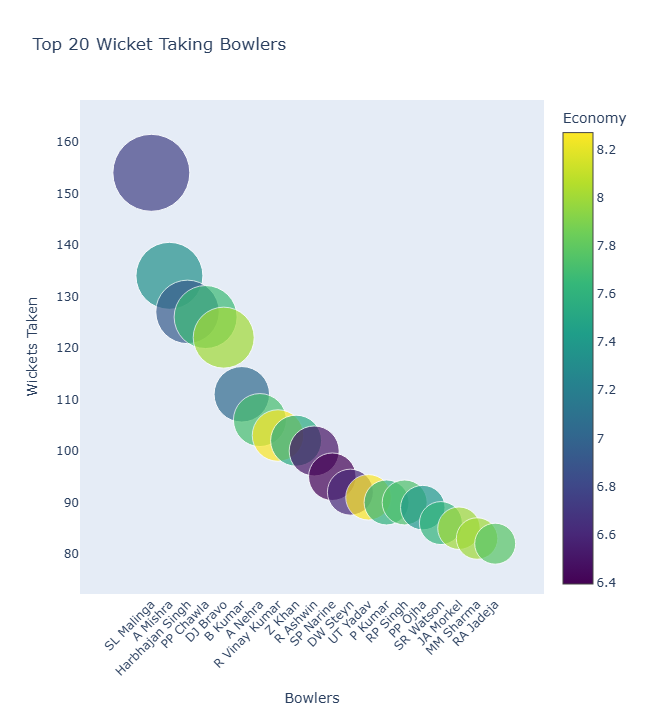

In [42]:
# Top 20 wicket-taking bowlers
bowlers = bowlers.sort_values(by='wickets', ascending=False).head(20)

# Scatter plot
trace = go.Scatter(
    x=bowlers['bowler'],
    y=bowlers['wickets'],
    mode='markers',
    marker=dict(
        size=bowlers['wickets'],
        color=bowlers['economy'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Economy'),
        sizemode='diameter',
        sizeref=2
    ),
    text=[
        f"Overs: {o:.1f}<br>Economy: {e:.2f}"
        for o, e in zip(bowlers['overs'], bowlers['economy'])
    ],
    hovertemplate=
        "<b>%{x}</b><br>" +
        "Wickets: %{y}<br>" +
        "%{text}<extra></extra>"
)

data = [trace]

layout = go.Layout(
    title='Top 20 Wicket Taking Bowlers',
    autosize=False,
    width=1100,
    height=700,
    hovermode='closest',

    xaxis=dict(
        title='Bowlers',
        tickangle=-45,
        automargin=True,
        showgrid=False,
        zeroline=False,
        showline=False
    ),

    yaxis=dict(
        title='Wickets Taken',
        showgrid=False,
        zeroline=False,
        showline=False
    ),

    showlegend=False
)

fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='scatter_bowlers')

Highest Dismissal for a Batsman by a Bowler

In [48]:
def get_top_bowler(batsman_name):

    dismissal_kinds = [
        'bowled',
        'caught',
        'lbw',
        'stumped',
        'caught and bowled',
        'hit wicket'
    ]

    batsman_data = delivery[delivery['batsman'] == batsman_name]

    batsman_data = batsman_data[
        batsman_data['dismissal_kind'].isin(dismissal_kinds)
    ]

    top_bowler = (
        batsman_data.groupby('bowler')
        .size()
        .reset_index(name='dismissals')
        .sort_values(by='dismissals', ascending=False)
        .head(1)
    )

    top_bowler['batsman'] = batsman_name

    return top_bowler

In [49]:
batsmen = ['CH Gayle', 'V Kohli', 'SK Raina', 'AB de Villiers', 'MS Dhoni', 'G Hambhir', 'RG Sharma', 'RV Uthappa', 'S Dhawan', 'DA Warner']

In [50]:
results = [get_top_bowler(batsman) for batsman in batsmen]

In [52]:
new = pd.concat(results, ignore_index = True)

Purple Caps Each Season

In [62]:
dismissal_kinds = [
    'bowled',
    'caught',
    'lbw',
    'stumped',
    'caught and bowled',
    'hit wicket'
]

purple = delivery[delivery['dismissal_kind'].isin(dismissal_kinds)]
purple = purple.merge(
    matches[['id', 'season']],
    left_on='match_id',
    right_on='id',
    how='left'
)
purple = purple.groupby(['season', 'bowler']).size().reset_index(name='wickets')
purple = purple.sort_values(['season', 'wickets'], ascending=[True, False])
purple = purple.drop_duplicates(subset='season', keep='first')
purple.head()


,season,bowler,wickets
75,2008,Sohail Tanvir,22
152,2009,RP Singh,23
241,2010,PP Ojha,21
367,2011,SL Malinga,28
437,2012,M Morkel,25


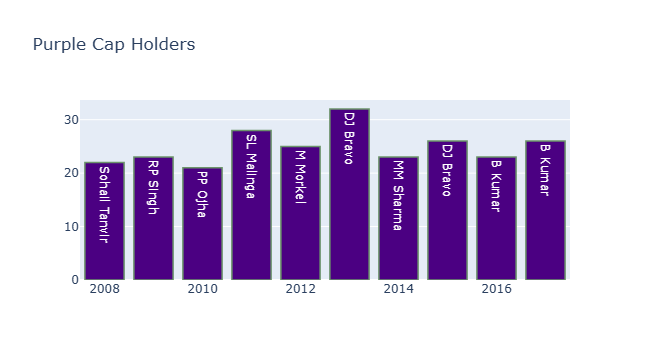

In [64]:
trace1 = go.Bar(
    x=purple['season'].values,
    y=purple['wickets'].values,
    name='Purple Cap',
    text=purple['bowler'].values,
    marker=dict(
        color='rgb(75, 0, 130)',
        line=dict(
            color='rgb(108, 148, 107)',
            width=1.5
        )
    ),
    opacity=1
)

layout = go.Layout(
    title='Purple Cap Holders'
)

data = [trace1]

fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='purple-cap-holders')